In [1]:
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score
from datetime import datetime
import keras
from mlp_ensemble import process_csv
from sklearn.metrics import r2_score, mean_squared_error

2025-12-10 06:46:39.135531: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-10 06:46:39.146363: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765349199.160059      82 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765349199.164652      82 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765349199.174940      82 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
def evaluate_by_input_features(
    base_folder="mlp_ensemble",
    variable="C",
    phi_threshold=0.1,
    dataset_comb=6
):
    summary_records = []

    # Load datasets once
    df_pig = process_csv('regularized_const_01C_C_only_englacial_temp_pig_r005_geo_12.csv')
    df_thwaites = process_csv('regularized_const_01C_C_only_englacial_temp_thwaites_r005_geo_12.csv')
    df_dotson = process_csv('regularized_const_01C_C_only_englacial_temp_dotson_r005_geo_12.csv')

    # Loop over dataset combinations
    for i in range(dataset_comb):

        # Determine dataset combination
        if i == 0:
            datasets = [df_dotson, df_thwaites]
            dataset_name = "dotson+thwaites"
        elif i == 1:
            datasets = [df_pig, df_thwaites]
            dataset_name = "pig+thwaites"
        elif i == 2:
            datasets = [df_dotson, df_pig]
            dataset_name = "dotson+pig"
        elif i == 3:
            datasets = [df_dotson]
            dataset_name = "dotson"
        elif i == 4:
            datasets = [df_pig]
            dataset_name = "pig"
        elif i == 5:
            datasets = [df_thwaites]
            dataset_name = "thwaites"
        else:
            raise ValueError(f"Dataset combination index {i} invalid.")

        print(f"\n=== Dataset combination {i}: {dataset_name} ===")

        # Build training dataset
        df_train = pd.concat(datasets, ignore_index=True)
        df_train = df_train[df_train["phi"] > phi_threshold].reset_index(drop=True)

        # Folder for this dataset combination
        current_folder = os.path.join(base_folder, f"mlp_ensemble_englacial_{i}")

        if not os.path.isdir(current_folder):
            print("Folder does not exist:", current_folder)
            continue

        # Loop over ensemble subfolders
        for folder in os.listdir(current_folder):
            try:
                folder_num = int(folder)
            except ValueError:
                continue  # Skip non-numeric subfolders

            path = os.path.join(current_folder, folder)
            if not os.path.isdir(path):
                continue

            print(f"Processing ensemble folder: {path}")

            pkl_files = [f for f in os.listdir(path) if f.endswith(".pkl")]
            if not pkl_files:
                print("  No .pkl files found, skipping.")
                continue

            # Reset per-ensemble inputs/features
            input_columns = None
            r2_list = []
            mse_list = []

            # Loop through all models for this ensemble
            for file in pkl_files:
                file_path = os.path.join(path, file)
                try:
                    with open(file_path, "rb") as f:
                        model_bundle = pickle.load(f)

                    # Extract required components
                    loaded_input_columns = model_bundle["input_columns"]
                    loaded_input_scaler = model_bundle["input_scaler"]
                    loaded_output_scaler = model_bundle["output_scaler"]
                    h5_filename = os.path.splitext(file)[0] + ".h5"
                    h5_path = os.path.join(path, h5_filename)

                    # Reset or validate input column consistency
                    if input_columns is None:
                        input_columns = tuple(loaded_input_columns)
                    else:
                        if input_columns != tuple(loaded_input_columns):
                            raise Exception(f"Input column mismatch inside ensemble {path}")

                    # Load model
                    loaded_model = keras.models.load_model(h5_path)

                    # Prepare data
                    df_local = df_train[list(input_columns)].copy()
                    X_scaled = loaded_input_scaler.transform(df_local.values)
                    y_true = df_train[variable].values.reshape(-1)

                    # Predict
                    pred_scaled = loaded_model.predict(X_scaled)
                    pred = loaded_output_scaler.inverse_transform(pred_scaled).reshape(-1)

                    # Compute metrics
                    r2 = r2_score(y_true, pred)
                    mse = mean_squared_error(y_true, pred)

                    r2_list.append(r2)
                    mse_list.append(mse)

                except Exception as e:
                    print(f"  Error loading model {file}: {e}")
                    continue

            # Skip empty ensemble
            if not r2_list:
                continue

            # Add one record per ensemble
            summary_records.append({
                "input_columns": input_columns,
                "dataset_combo": dataset_name,
                "r2_median": np.median(r2_list),
                "mse_median": np.median(mse_list),
                "n_models": len(r2_list),
                "r2_list": r2_list,
                "mse_list": mse_list,
            })

    # Convert to DataFrame
    summary = pd.DataFrame(summary_records)

    if summary.empty:
        print("No valid models processed; summary is empty.")
        return summary, None, None

    # Pivot table: rows = input columns, columns = dataset combos
    summary_r2 = summary.pivot_table(
        index="input_columns", columns="dataset_combo", values="r2_median"
    )

    summary_mse = summary.pivot_table(
        index="input_columns", columns="dataset_combo", values="mse_median"
    )

    return summary, summary_r2, summary_mse


In [2]:
summary, summary_r2, summary_mse = evaluate_by_input_features(
    base_folder="mlp_ensemble",
    variable="C",
    phi_threshold=0.1,
    
)
#summary.to_csv("summary.csv")
#summary_r2.to_csv("summary_r2.csv")
#summary_mse.to_csv("summary_mse.csv")

NameError: name 'evaluate_by_input_features' is not defined

In [3]:
summary_r2

NameError: name 'summary_r2' is not defined

In [4]:
df = pd.read_csv('summary_r2.csv')

In [5]:
df["input_columns"][df["input_columns"].duplicated()].unique()


array([], dtype=object)

In [6]:
df_clean = df.copy()

# Convert input_columns tuple → clean comma-joined string
def tuple_to_string(x):
    if isinstance(x, tuple):
        return ", ".join(x)
    return str(x)

df_clean["features_str"] = df_clean["input_columns"].apply(tuple_to_string)

# Now set the cleaned string column as the index
df_clean = df_clean.set_index("features_str")

df_clean.index = (
    df_clean.index
        .str.replace(r"[()']", "", regex=True)   # remove parentheses and quotes
        .str.replace(r"\s+", " ", regex=True)    # normalize whitespace
        .str.replace(", ", ", ")                  # enforce consistent comma-spacing
        .str.strip()
)


In [7]:
print(df_clean.index[:5])
print(type(df_clean.index[0]))

Index(['b, mag_b, gravity_disturbance', 'b, mag_b, heatflux',
       'b, mag_b, heatflux, gravity_disturbance',
       'b, mag_b, heatflux, mag_anomaly',
       'b, mag_b, heatflux, s, h, mag_h, mag_s, surface_air_temp'],
      dtype='object', name='features_str')
<class 'str'>


In [8]:
desired_order = [
    's, b, h, mag_h, mag_s, mag_b, driving_stress, heatflux, surface_air_temp, gravity_disturbance, mag_anomaly',
    's, b, h, mag_h, mag_s, mag_b, driving_stress, heatflux, surface_air_temp, gravity_disturbance',
    's, b, h, mag_h, mag_s, mag_b, driving_stress, heatflux, surface_air_temp, mag_anomaly',
    's, b, h, mag_h, mag_s, mag_b, heatflux, surface_air_temp',
    's, h, mag_h, mag_s, driving_stress, surface_air_temp',
    's, h, mag_h, mag_s, driving_stress',
    's, h, mag_h, mag_s, surface_air_temp',
    's, h, mag_h, mag_s',
    'mag_h, mag_s',
    's, h',
    'b, mag_b, gravity_disturbance',
    'b, mag_b, heatflux, gravity_disturbance',
    'b, mag_b, heatflux',
    'heatflux, gravity_disturbance',
    'b, mag_b, mag_anomaly',
    'b, mag_b, heatflux, mag_anomaly',
    'heatflux, mag_anomaly',
]


In [9]:
# Keep only the rows that exist
valid_order = [x for x in desired_order if x in df_clean.index]

# Reorder
df_reordered = df_clean.loc[valid_order]

df_reordered


,input_columns,dotson,dotson+pig,dotson+thwaites,pig,pig+thwaites,thwaites
features_str,,,,,,,
"s, b, h, mag_h, mag_s, mag_b, driving_stress, heatflux, surface_air_temp, gravity_disturbance, mag_anomaly","('s', 'b', 'h', 'mag_h', 'mag_s', 'mag_b', 'dr...",0.994485,0.995787,0.994592,0.997545,0.975348,0.988083
"s, b, h, mag_h, mag_s, mag_b, driving_stress, heatflux, surface_air_temp, gravity_disturbance","('s', 'b', 'h', 'mag_h', 'mag_s', 'mag_b', 'dr...",0.995729,0.997430,0.994089,0.996608,0.975426,0.990212
"s, b, h, mag_h, mag_s, mag_b, driving_stress, heatflux, surface_air_temp, mag_anomaly","('s', 'b', 'h', 'mag_h', 'mag_s', 'mag_b', 'dr...",0.994268,0.996642,0.993937,0.992276,0.977141,0.987350
"s, h, mag_h, mag_s, driving_stress, surface_air_temp","('s', 'h', 'mag_h', 'mag_s', 'driving_stress',...",0.969464,0.979398,0.950950,0.989081,0.955972,0.950315
"s, h, mag_h, mag_s, driving_stress","('s', 'h', 'mag_h', 'mag_s', 'driving_stress')",0.846998,0.847567,0.703185,0.936129,0.788084,0.706654
"s, h, mag_h, mag_s, surface_air_temp","('s', 'h', 'mag_h', 'mag_s', 'surface_air_temp')",0.967562,0.975237,0.943337,0.986241,0.951750,0.953528
"s, h, mag_h, mag_s","('s', 'h', 'mag_h', 'mag_s')",0.857784,0.871444,0.756594,0.938558,0.791368,0.754342
"mag_h, mag_s","('mag_h', 'mag_s')",0.238185,0.240260,0.201367,0.161551,0.115215,0.131991
"s, h","('s', 'h')",0.464822,0.620359,0.628900,0.754190,0.585108,0.649163


In [10]:
missing = set(desired_order) - set(df_clean.index)
missing


{'s, b, h, mag_h, mag_s, mag_b, heatflux, surface_air_temp'}

In [11]:
import pandas as pd

# ------------------------------------------------------------
# 1. Ultra-fast canonicalizer for tuples
# ------------------------------------------------------------

def canonicalize_tuple_fast(x):
    # If already a tuple, this is extremely fast
    if isinstance(x, tuple):
        return ", ".join(sorted(x))
    # If string, only then parse (rare slow path)
    parts = x.replace("(", "").replace(")", "").replace("'", "").split(",")
    parts = [p.strip() for p in parts if p.strip()]
    return ", ".join(sorted(parts))


# ------------------------------------------------------------
# 2. Canonicalize DataFrame input column (FAST)
# ------------------------------------------------------------

df_clean = df.copy()
df_clean["canonical"] = df_clean["input_columns"].apply(canonicalize_tuple_fast)
df_clean = df_clean.set_index("canonical")


# ------------------------------------------------------------
# 3. Canonicalize desired_order (FAST)
# ------------------------------------------------------------

def canon_str_fast(s):
    parts = [p.strip() for p in s.split(",")]
    return ", ".join(sorted(parts))

desired_order_canon = [canon_str_fast(s) for s in desired_order]


# ------------------------------------------------------------
# 4. Reorder (FAST because index lookups are O(1))
# ------------------------------------------------------------

valid_order = [c for c in desired_order_canon if c in df_clean.index]
df_reordered = df_clean.loc[valid_order].reset_index().rename(columns={"canonical": "canonical_features"})

df_reordered


,canonical_features,input_columns,dotson,dotson+pig,dotson+thwaites,pig,pig+thwaites,thwaites
0,"b, driving_stress, gravity_disturbance, h, hea...","('s', 'b', 'h', 'mag_h', 'mag_s', 'mag_b', 'dr...",0.994485,0.995787,0.994592,0.997545,0.975348,0.988083
1,"b, driving_stress, gravity_disturbance, h, hea...","('s', 'b', 'h', 'mag_h', 'mag_s', 'mag_b', 'dr...",0.995729,0.997430,0.994089,0.996608,0.975426,0.990212
2,"b, driving_stress, h, heatflux, mag_anomaly, m...","('s', 'b', 'h', 'mag_h', 'mag_s', 'mag_b', 'dr...",0.994268,0.996642,0.993937,0.992276,0.977141,0.987350
3,"b, h, heatflux, mag_b, mag_h, mag_s, s, surfac...","('b', 'mag_b', 'heatflux', 's', 'h', 'mag_h', ...",0.995496,0.995124,0.991104,0.995829,0.982535,0.990939
4,"driving_stress, h, mag_h, mag_s, s, surface_ai...","('s', 'h', 'mag_h', 'mag_s', 'driving_stress',...",0.969464,0.979398,0.950950,0.989081,0.955972,0.950315
5,"driving_stress, h, mag_h, mag_s, s","('s', 'h', 'mag_h', 'mag_s', 'driving_stress')",0.846998,0.847567,0.703185,0.936129,0.788084,0.706654
6,"h, mag_h, mag_s, s, surface_air_temp","('s', 'h', 'mag_h', 'mag_s', 'surface_air_temp')",0.967562,0.975237,0.943337,0.986241,0.951750,0.953528
7,"h, mag_h, mag_s, s","('s', 'h', 'mag_h', 'mag_s')",0.857784,0.871444,0.756594,0.938558,0.791368,0.754342
8,"mag_h, mag_s","('mag_h', 'mag_s')",0.238185,0.240260,0.201367,0.161551,0.115215,0.131991
9,"h, s","('s', 'h')",0.464822,0.620359,0.628900,0.754190,0.585108,0.649163


In [12]:
desired_order_canon = [canon_str_fast(s) for s in desired_order]

missing = set(desired_order_canon) - set(df_clean.index)
missing


set()

In [13]:
rename_map = {
    "dotson": "Dotson",
    "dotson+pig": "Dotson+Pig",
    "dotson+thwaites": "Dotson+Thwaites",
    "pig": "Pig",
    "pig+thwaites": "Pig+Thwaites",
    "thwaites": "Thwaites",
}
df_reordered = df_reordered.rename(columns=rename_map)


In [14]:
new_col_order = [
    "Dotson+Thwaites",   # Thwaites + Dotson
    "Pig+Thwaites",      # Thwaites + Pig
    "Dotson+Pig",        # Pig + Dotson
    "Dotson",            # Dotson
    "Pig",               # Pig
    "Thwaites"           # Thwaites
]
df_reordered = df_reordered[new_col_order]


In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Feature symbol mapping (your definitions)
# ------------------------------------------------------------
FEATURE_SYMBOLS = {
    "s": r"$s$",
    "b": r"$b$",
    "h": r"$h$",

    # Gradient magnitudes (heatmap-safe LaTeX)
    "mag_s": r"$\left| \nabla s \right|$",
    "mag_b": r"$\left| \nabla b \right|$",
    "mag_h": r"$\left| \nabla h \right|$",

    "driving_stress": r"$\tau_d$",
    "gravity_disturbance": r"$g_d$",
    "heatflux": r"$Q_b$",
    "surface_air_temp": r"$T_s$",
    "snow_accumulation": r"$A_s$",
    "mag_anomaly": r"$m_a$",
}



#DATASET_NAMES = ["Dotson", "Dotson+Pig", "Dotson+Thwaites", "Pig", "Pig+Thwaites", "Thwaites"]
DATASET_NAMES = new_col_order



# ------------------------------------------------------------
# Helper: convert canonical feature strings → LaTeX symbol labels
# ------------------------------------------------------------
def replace_features_with_symbols(feature_labels):
    """
    feature_labels: list of canonical feature strings, example:
        "b, h, mag_h, mag_s, s, surface_air_temp"
    returns a list with LaTeX symbols in the same order:
       "
    """
    symbol_labels = []
    for label in feature_labels:
        features = [x.strip() for x in label.split(",")]
        symbols = [FEATURE_SYMBOLS.get(f, f) for f in features]
        symbol_labels.append(", ".join(symbols))
    return symbol_labels


# ------------------------------------------------------------
# Main plotting function
# ------------------------------------------------------------
def plot_r2_heatmap_with_symbols_new(r2_scores, feature_labels, save_path=None):
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    feature_symbols = replace_features_with_symbols(feature_labels)

    r2_df = pd.DataFrame(
        np.array(r2_scores).reshape(len(feature_labels), len(DATASET_NAMES)),
        columns=DATASET_NAMES,
        index=feature_symbols
    )

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        r2_df,
        annot=True,
        fmt=".2f",
        cmap="YlGn",
        cbar=True,
        vmin=0,
        vmax=1,
        annot_kws={"size": 11}
    )

    plt.title("Training $R^2$ Scores for Feature Subsets and Training Catchments", fontsize=16)
    plt.ylabel("Feature Subsets", fontsize=14)
    plt.xlabel("Training Dataset Combinations", fontsize=14)
    plt.tight_layout()

    # ------------------------------------------------------------
    # SAVE IF A PATH IS PROVIDED
    # ------------------------------------------------------------
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved heatmap to: {save_path}")

    plt.show()


Saved heatmap to: r2_feature_heatmap.png


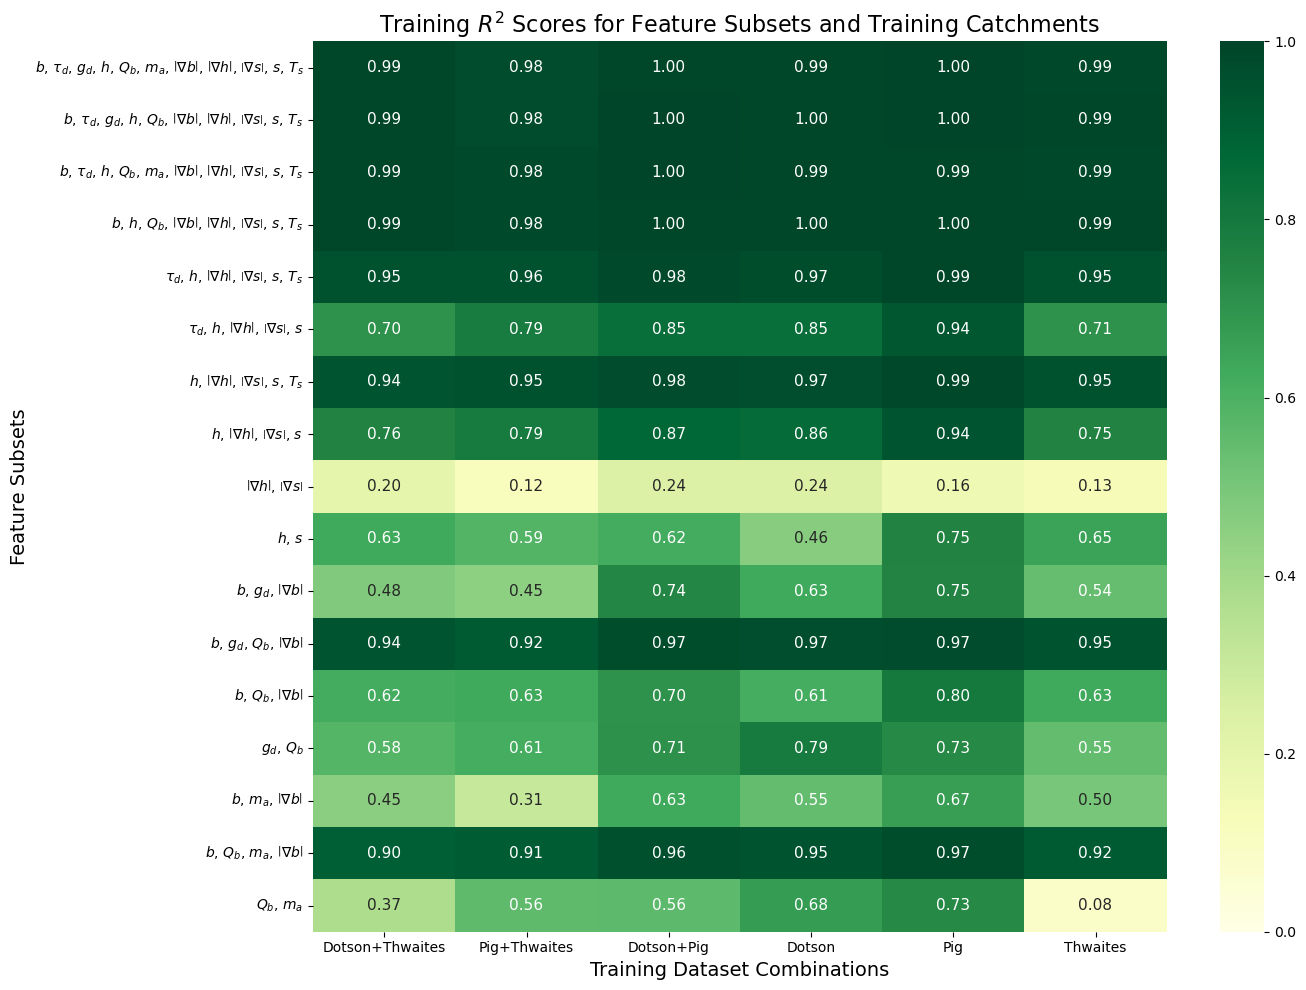

In [16]:
feature_labels = valid_order  # canonical strings
r2_scores = df_reordered[DATASET_NAMES].values

plot_r2_heatmap_with_symbols_new(
    r2_scores,
    feature_labels,
    save_path="r2_feature_heatmap.png"
)


Saved heatmap to: heatmap_r2.png


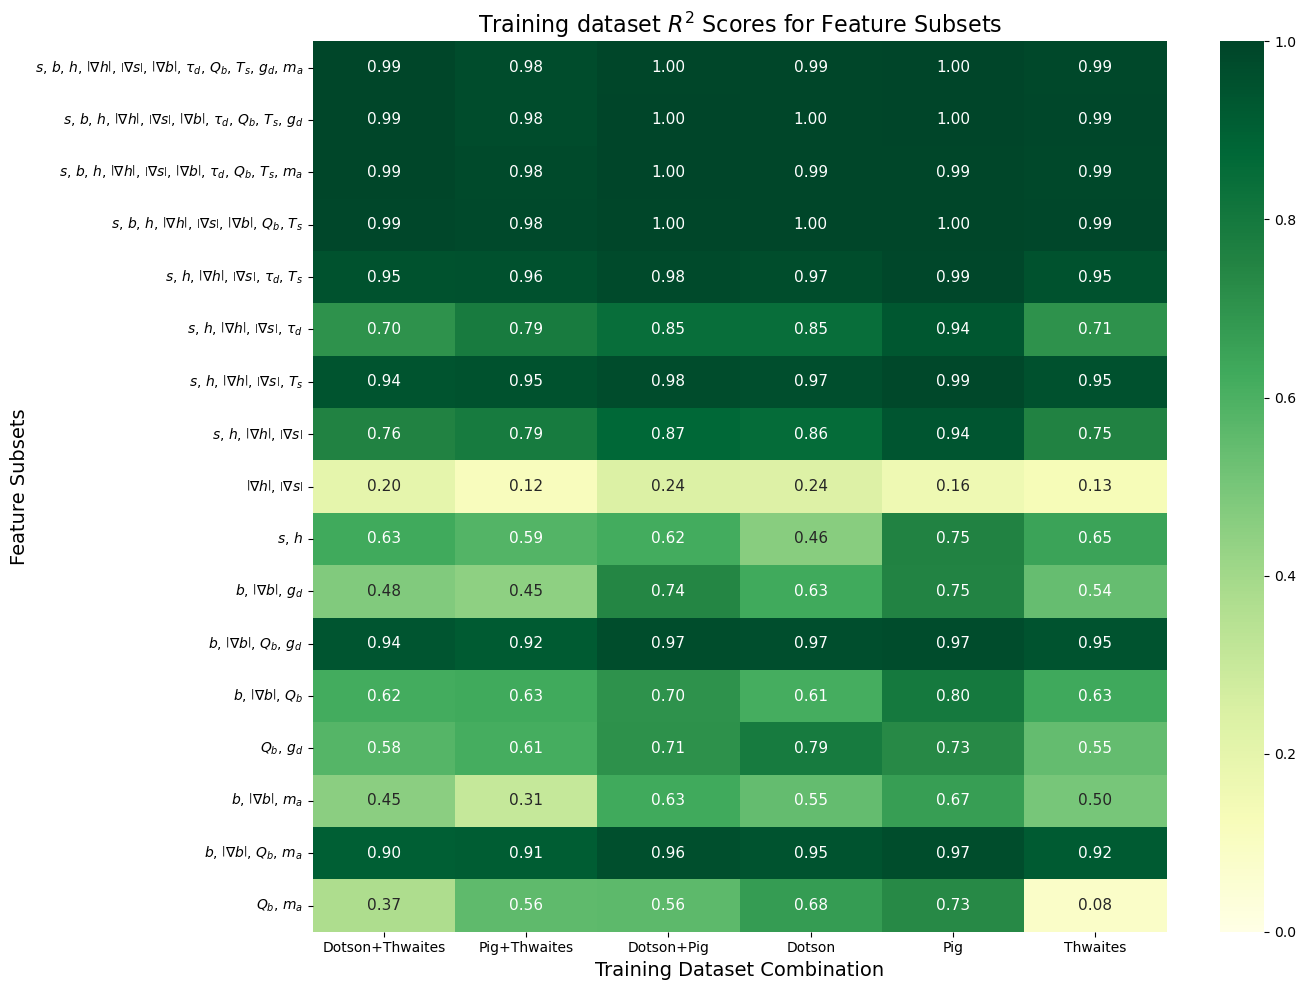

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. Canonicalization utilities (FAST)
# ============================================================

def canonicalize_tuple_fast(x):
    """Convert tuple to canonical sorted string."""
    if isinstance(x, tuple):
        return ", ".join(sorted(x))
    parts = x.replace("(", "").replace(")", "").replace("'", "").split(",")
    parts = [p.strip() for p in parts if p.strip()]
    return ", ".join(sorted(parts))

def canonicalize_string(s):
    """Canonicalize a comma-separated feature string."""
    parts = [p.strip() for p in s.split(",")]
    parts = [p for p in parts if p]
    return ", ".join(sorted(parts))


# ============================================================
# 2. Desired feature order (your exact internal ordering)
# ============================================================

desired_order = [
    's, b, h, mag_h, mag_s, mag_b, driving_stress, heatflux, surface_air_temp, gravity_disturbance, mag_anomaly',
    's, b, h, mag_h, mag_s, mag_b, driving_stress, heatflux, surface_air_temp, gravity_disturbance',
    's, b, h, mag_h, mag_s, mag_b, driving_stress, heatflux, surface_air_temp, mag_anomaly',
    's, b, h, mag_h, mag_s, mag_b, heatflux, surface_air_temp',
    's, h, mag_h, mag_s, driving_stress, surface_air_temp',
    's, h, mag_h, mag_s, driving_stress',
    's, h, mag_h, mag_s, surface_air_temp',
    's, h, mag_h, mag_s',
    'mag_h, mag_s',
    's, h',
    'b, mag_b, gravity_disturbance',
    'b, mag_b, heatflux, gravity_disturbance',
    'b, mag_b, heatflux',
    'heatflux, gravity_disturbance',
    'b, mag_b, mag_anomaly',
    'b, mag_b, heatflux, mag_anomaly',
    'heatflux, mag_anomaly',
]

desired_order_canon = [canonicalize_string(d) for d in desired_order]


# ============================================================
# 3. Build mapping: canonical → original ordering (display labels)
# ============================================================

canon_to_original = {canonicalize_string(d): d for d in desired_order}


# ============================================================
# 4. Canonicalize DataFrame rows and reorder
# ============================================================

df_clean = df.copy()
df_clean["canonical"] = df_clean["input_columns"].apply(canonicalize_tuple_fast)
df_clean = df_clean.set_index("canonical")

# Match only those in desired_order
valid_order = [c for c in desired_order_canon if c in df_clean.index]

# Reorder dataframe
df_reordered = df_clean.loc[valid_order].copy()

# Recover original (non-sorted) display strings
feature_labels = [canon_to_original[c] for c in valid_order]


# ============================================================
# 5. Rename dataset columns to capitals
# ============================================================

rename_map = {
    "dotson": "Dotson",
    "dotson+pig": "Dotson+Pig",
    "dotson+thwaites": "Dotson+Thwaites",
    "pig": "Pig",
    "pig+thwaites": "Pig+Thwaites",
    "thwaites": "Thwaites",
}
df_reordered = df_reordered.rename(columns=rename_map)

DATASET_NAMES = [
    "Dotson+Thwaites",   # Thwaites + Dotson
    "Pig+Thwaites",      # Thwaites + Pig
    "Dotson+Pig",        # Pig + Dotson
    "Dotson",            # Dotson
    "Pig",               # Pig
    "Thwaites"           # Thwaites
]


# ============================================================
# 6. Feature LaTeX symbols
# ============================================================

FEATURE_SYMBOLS = {
    "s": r"$s$",
    "b": r"$b$",
    "h": r"$h$",

    # Norms using left/right bars (mathtext-compatible)
    "mag_s": r"$\left| \nabla s \right|$",
    "mag_b": r"$\left| \nabla b \right|$",
    "mag_h": r"$\left| \nabla h \right|$",

    "driving_stress": r"$\tau_d$",
    "gravity_disturbance": r"$g_d$",
    "heatflux": r"$Q_b$",
    "surface_air_temp": r"$T_s$",
    "snow_accumulation": r"$A_s$",
    "mag_anomaly": r"$m_a$",
}

def replace_features_with_symbols(feature_labels):
    symbol_labels = []
    for label in feature_labels:
        parts = [x.strip() for x in label.split(",")]
        symbols = [FEATURE_SYMBOLS.get(f, f) for f in parts]
        symbol_labels.append(", ".join(symbols))
    return symbol_labels


# ============================================================
# 7. Heatmap plotting function
# ============================================================

def plot_r2_heatmap_with_symbols_new(r2_scores, feature_labels, save_path=None):
    feature_symbols = replace_features_with_symbols(feature_labels)

    r2_df = pd.DataFrame(r2_scores, columns=DATASET_NAMES, index=feature_symbols)

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        r2_df,
        annot=True,
        fmt=".2f",
        cmap="YlGn",
        cbar=True,
        vmin=0,
        vmax=1,
        annot_kws={"size": 11}
    )

    plt.title("Training dataset $R^2$ Scores for Feature Subsets", fontsize=16)
    plt.ylabel("Feature Subsets", fontsize=14)
    plt.xlabel("Training Dataset Combination", fontsize=14)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved heatmap to: {save_path}")

    plt.show()


# ============================================================
# 8. Run heatmap
# ============================================================

r2_scores = df_reordered[DATASET_NAMES].values
plot_r2_heatmap_with_symbols_new(r2_scores, feature_labels, save_path="heatmap_r2.png")
